In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.preprocessing import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17501 entries, 0 to 17500
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               17501 non-null  datetime64[ns]
 1   Close               17501 non-null  float64       
 2   Ticker              17501 non-null  object        
 3   Retorno_Mensual     17149 non-null  float64       
 4   Varianza_Activo     17149 non-null  float64       
 5   Covarianza_Mercado  17149 non-null  float64       
 6   MarketCap           17445 non-null  float64       
 7   EnterpriseValue     17445 non-null  float64       
 8   PE_Trailing         17407 non-null  float64       
 9   EnterpriseToEbitda  17445 non-null  float64       
 10  PriceToBook         17397 non-null  float64       
 11  operatingMargins    17501 non-null  float64       
 12  profitMargins       17463 non-null  float64       
 13  returnOnEquity      17415 non-null  float64   

In [3]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [4]:
# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
Fecha,17501,2024-11-03 16:23:54.980858112,2022-07-01 00:00:00,2024-02-01 00:00:00,2024-11-01 00:00:00,2025-09-01 00:00:00,2026-06-01 00:00:00,NaN
Retorno_Mensual,17149.0,0.01,-0.52,-0.04,0.01,0.06,1.43,0.1
Varianza_Activo,17149.0,0.01,0.0,0.0,0.01,0.01,0.37,0.01
Covarianza_Mercado,17149.0,0.0,-0.0,0.0,0.0,0.0,0.02,0.0
MarketCap,17445.0,108.89,1.3,18.3,35.25,77.13,5178.51,352.44
EnterpriseValue,17445.0,120.89,3.23,22.88,43.82,90.93,5179.9,356.83
PE_Trailing,17407.0,-14.75,-102361.02,15.51,24.3,36.79,5658.65,2016.61
EnterpriseToEbitda,17445.0,23.14,-1813.33,11.08,15.88,22.29,3204.7,99.32
PriceToBook,17397.0,7.2,-1029.45,1.88,3.78,8.23,1349.78,52.56
operatingMargins,17501.0,0.19,-1.6,0.11,0.18,0.26,0.93,0.15


In [5]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Retorno_Mensual        1.533254
Varianza_Activo       12.017534
Covarianza_Mercado     1.364425
MarketCap              8.233447
EnterpriseValue        8.099576
PE_Trailing          -40.949008
EnterpriseToEbitda    13.316107
PriceToBook            7.355179
operatingMargins      -0.395789
profitMargins         -1.930305
returnOnEquity         0.879090
ReturnOnAssets         0.699855
debtToEquity          -3.973226
currentRatio           6.780314
FEDFUNDS              -0.466271
GS10                  -0.623088
T10Y2Y                -0.274215
CPIAUCSL               0.060556
UNRATE                -0.410407
dtype: float64

Cont


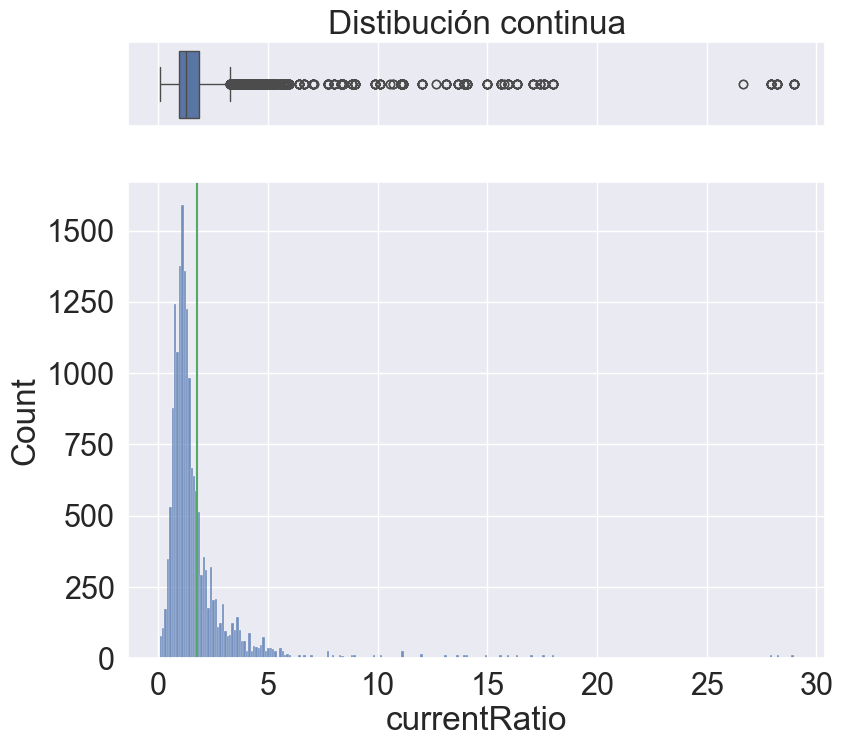

In [6]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [7]:
# Transformacion yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [8]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Retorno_Mensual                    1.533254
Varianza_Activo                   12.017534
Covarianza_Mercado                 1.364425
operatingMargins                  -0.395789
profitMargins                     -1.930305
ReturnOnAssets                     0.699855
FEDFUNDS                          -0.466271
GS10                              -0.623088
T10Y2Y                            -0.274215
CPIAUCSL                           0.060556
UNRATE                            -0.410407
PriceToBook_Transformed            4.185760
returnOnEquity_Transformed        -0.234053
PE_Trailing_Transformed            9.567582
EnterpriseToEbitda_Transformed     9.152377
MarketCap_log                      1.144205
EnterpriseValue_log                1.095430
debtToEquity_log                   2.409165
currentRatio_log                   1.886858
dtype: float64

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [9]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Retorno_Mensual
Varianza_Activo
Covarianza_Mercado
operatingMargins
profitMargins
ReturnOnAssets
FEDFUNDS
GS10
T10Y2Y
CPIAUCSL
UNRATE
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [10]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Retorno_Mensual                   0.462854
Varianza_Activo                   1.760406
Covarianza_Mercado                1.013192
operatingMargins                  0.510513
profitMargins                     0.147822
ReturnOnAssets                    0.568951
FEDFUNDS                         -0.466271
GS10                             -0.623088
T10Y2Y                           -0.274215
CPIAUCSL                          0.060556
UNRATE                           -0.410407
PriceToBook_Transformed           0.211255
returnOnEquity_Transformed        0.964553
PE_Trailing_Transformed           0.944437
EnterpriseToEbitda_Transformed    0.947410
MarketCap_log                     1.144205
EnterpriseValue_log               1.095430
debtToEquity_log                  1.523073
currentRatio_log                  1.230913
dtype: float64

Cont


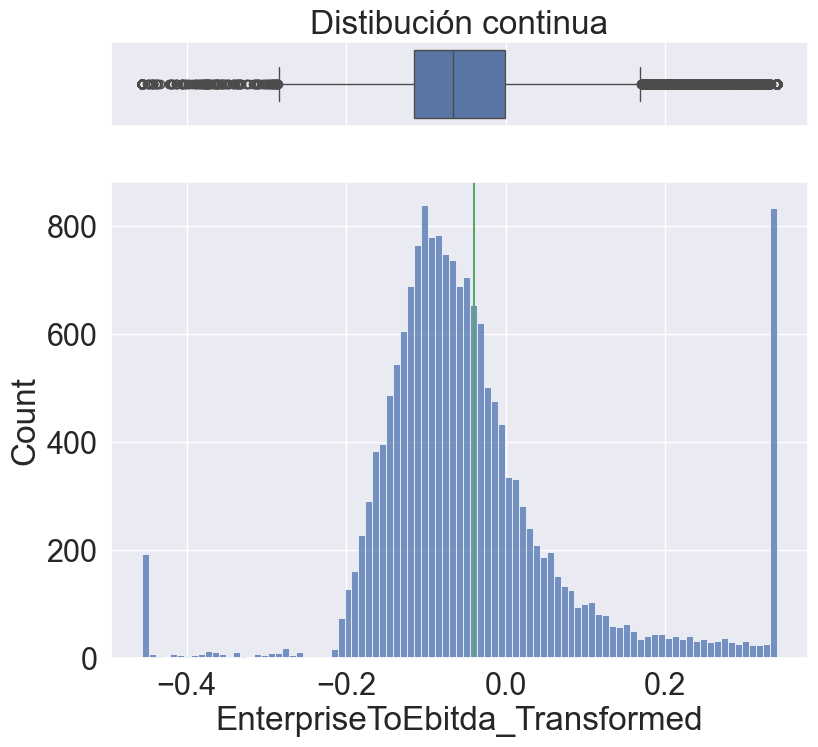

In [11]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [13]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Beta,71247.0,9.043533e-01,5.870032e-01,-1.487400e+00,4.896000e-01,8.625000e-01,1.241400e+00,3.503800e+00
operatingMargins,78949.0,1.916694e-01,1.407006e-01,-3.598000e-01,1.065000e-01,1.781000e-01,2.611000e-01,7.419000e-01
profitMargins,78778.0,1.358582e-01,1.301090e-01,-3.532000e-01,6.690000e-02,1.215000e-01,1.971000e-01,6.031000e-01
ReturnOnAssets,78739.0,7.941346e-02,7.724753e-02,-2.277000e-01,3.290000e-02,6.370000e-02,1.176000e-01,3.887000e-01
PriceToBook_Transformed,78498.0,-1.710573e-02,1.645015e-01,-4.330244e-01,-8.459779e-02,-4.960207e-02,3.146023e-02,3.798868e-01
returnOnEquity_Transformed,78568.0,-8.185146e-03,4.670536e-01,-3.149529e+00,-5.780092e-02,-2.156078e-02,4.320531e-02,3.264760e+00
PE_Trailing_Transformed,78537.0,-5.130077e-02,6.220921e-02,-2.386263e-01,-8.509084e-02,-6.421677e-02,-3.393556e-02,1.195444e-01
EnterpriseToEbitda_Transformed,78708.0,-4.085822e-02,1.432806e-01,-4.875086e-01,-1.209290e-01,-6.772821e-02,1.260540e-03,3.678755e-01
MarketCap_log,78708.0,6.181105e-08,6.587769e-08,6.997463e-10,1.810272e-08,3.479989e-08,7.561068e-08,2.482535e-07
EnterpriseValue_log,78708.0,7.445922e-08,7.668719e-08,2.611904e-09,2.261354e-08,4.332537e-08,8.939324e-08,2.897625e-07


# Variables Categoricas

In [12]:
df_non_numeric = df.select_dtypes(exclude='number')

In [13]:
# Valores unicos
df_non_numeric.nunique()

Fecha           48
Ticker         454
Sector          11
SubIndustry    119
DateAdded      338
dtype: int64

In [14]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials              3048
InformationTechnology    2738
HealthCare               2147
ConsumerDiscretionary    1842
ConsumerStaples          1436
Financials               1232
RealEstate               1178
Utilities                1143
Materials                 997
CommunicationServices     905
Energy                    835
Name: count, dtype: int64

In [15]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
HealthCareEquipment                        622
ElectricUtilities                          570
ApplicationSoftware                        550
Semiconductors                             542
IndustrialMachinery&Supplies&Components    540
                                          ... 
FoodRetail                                  37
HomefurnishingRetail                        37
Footwear                                    35
HeavyElectricalEquipment                    27
HealthCareTechnology                        27
Name: count, Length: 119, dtype: int64

In [16]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Fecha,Ticker,Sector,SubIndustry,DateAdded


In [17]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [18]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Fecha,Ticker,Sector,SubIndustry,YearsSinceAdded,Retorno_Mensual,Varianza_Activo,Covarianza_Mercado,operatingMargins,profitMargins,...,CPIAUCSL,UNRATE,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-03-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,300.420,3.5,0.021369,0.01192,-0.050262,-0.003379,3.722424,3.763071,0.420025,1.108596
1,2023-04-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.021035,0.005672,0.003620,0.2363,0.1831,...,301.450,3.6,0.018336,0.01192,-0.052109,-0.007876,3.701683,3.743165,0.420025,1.108596
2,2023-05-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.144514,0.007249,0.003212,0.2363,0.1831,...,301.821,3.5,-0.002086,0.01192,-0.064356,-0.038162,3.549758,3.597885,0.420025,1.108596
3,2023-06-01,A,HealthCare,LifeSciencesTools&Services,26.0,0.039595,0.006755,0.003150,0.2363,0.1831,...,302.845,3.4,0.002706,0.01192,-0.061515,-0.031056,3.587495,3.633880,0.420025,1.108596
4,2023-07-01,A,HealthCare,LifeSciencesTools&Services,26.0,0.014574,0.006177,0.002911,0.2363,0.1831,...,303.334,3.6,0.004538,0.01192,-0.060423,-0.028339,3.601567,3.647318,0.420025,1.108596


# Missings

In [19]:
df_combined.isnull().sum()

Fecha                                0
Ticker                               0
Sector                               0
SubIndustry                          0
YearsSinceAdded                      0
Retorno_Mensual                    352
Varianza_Activo                    352
Covarianza_Mercado                 352
operatingMargins                     0
profitMargins                       38
ReturnOnAssets                      48
FEDFUNDS                             1
GS10                                 1
T10Y2Y                               1
CPIAUCSL                           455
UNRATE                             455
PriceToBook_Transformed            104
returnOnEquity_Transformed          86
PE_Trailing_Transformed             94
EnterpriseToEbitda_Transformed      56
MarketCap_log                       56
EnterpriseValue_log                 56
debtToEquity_log                  1272
currentRatio_log                    10
dtype: int64

In [20]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [21]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17501 entries, 0 to 17500
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 17501 non-null  float64
 1   Retorno_Mensual                 17501 non-null  float64
 2   Varianza_Activo                 17501 non-null  float64
 3   Covarianza_Mercado              17501 non-null  float64
 4   operatingMargins                17501 non-null  float64
 5   profitMargins                   17501 non-null  float64
 6   ReturnOnAssets                  17501 non-null  float64
 7   FEDFUNDS                        17501 non-null  float64
 8   GS10                            17501 non-null  float64
 9   T10Y2Y                          17501 non-null  float64
 10  CPIAUCSL                        17501 non-null  float64
 11  UNRATE                          17501 non-null  float64
 12  PriceToBook_Transformed         

In [22]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17501 entries, 0 to 17500
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   YearsSinceAdded                 17501 non-null  float64       
 1   Retorno_Mensual                 17501 non-null  float64       
 2   Varianza_Activo                 17501 non-null  float64       
 3   Covarianza_Mercado              17501 non-null  float64       
 4   operatingMargins                17501 non-null  float64       
 5   profitMargins                   17501 non-null  float64       
 6   ReturnOnAssets                  17501 non-null  float64       
 7   FEDFUNDS                        17501 non-null  float64       
 8   GS10                            17501 non-null  float64       
 9   T10Y2Y                          17501 non-null  float64       
 10  CPIAUCSL                        17501 non-null  float64       
 11  UN

In [23]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.037565
Retorno_Mensual                   0.478263
Varianza_Activo                   1.744699
Covarianza_Mercado                0.959184
operatingMargins                  0.510513
profitMargins                     0.143628
ReturnOnAssets                    0.563095
FEDFUNDS                         -0.466279
GS10                             -0.623101
T10Y2Y                           -0.274216
CPIAUCSL                          0.008832
UNRATE                           -0.454439
PriceToBook_Transformed           0.208732
returnOnEquity_Transformed        0.967740
PE_Trailing_Transformed           0.938885
EnterpriseToEbitda_Transformed    0.951121
MarketCap_log                     1.147717
EnterpriseValue_log               1.097347
debtToEquity_log                  0.068804
currentRatio_log                  1.230189
dtype: float64

In [24]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")